# Assignment 6: Emotion Classification

**Data:**

The dataset is available at Emotion Classification NLP | Kaggle . Acknowledgment: WASSA-2017 Shared Task on Emotion Intensity. Saif M. Mohammad and Felipe Bravo-Marquez. In Proceedings of the EMNLP 2017 Workshop on Computational Approaches to Subjectivity, Sentiment, and Social Media (WASSA), September 2017, Copenhagen, Denmark. 

**Problem Statement:**

Identifying the emotion behind human text is an important part of NLP for various applications including customer review analysis and artificial intelligence. The owner of Twitter, Elon Musk has fired everyone who understood emotion classification of tweets because they were not "hard core" enough, and now their existing model is no longer working. As a new employee, your job is to develop a model that can classify the emotional connotation behind tweets. Mr. Musk does not disclose why this is needed but laughs eerily whenever asked about it.

# 1. Data
## 1.1 Load Data
Load the three datafiles into training, validation, and testing dataframes.

In [1]:
import pandas as pd
df_train = pd.read_csv('datasets/emotion-labels-train.csv')
df_validation = pd.read_csv('datasets/emotion-labels-val.csv')
df_test = pd.read_csv('datasets/emotion-labels-test.csv')

In [2]:
df_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


## 1.2 Validating Datasets
Use pandas.DataFrame.info to check if the entries are the correct datatype, and if there are any missing values. Use pandas.DataFrame.duplicates to check for duplicate entries. Fix the dataset so that there are no missing values, duplicate rows, or incorrect data types. Use markdown to make observations and explain what you have done.

### Missingness Check

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3613 entries, 0 to 3612
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3613 non-null   object
 1   label   3613 non-null   object
dtypes: object(2)
memory usage: 56.6+ KB


In [4]:
df_validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    347 non-null    object
 1   label   347 non-null    object
dtypes: object(2)
memory usage: 5.5+ KB


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3142 non-null   object
 1   label   3142 non-null   object
dtypes: object(2)
memory usage: 49.2+ KB


### Duplicates Check

In [6]:
print("Train:", df_train.duplicated().sum())
print("Validation:", df_validation.duplicated().sum())
print("Test:", df_test.duplicated().sum())

Train: 0
Validation: 0
Test: 0


No missing values or duplicates were found on any of the datasets

## 1.3 Separating Labels
Move the labels into a separate dataframe and use sklearn.preprocessing.LabelEncoder to convert the string labels into integers. Reshape the labels into a 2d array. Determine which number has been assigned to each label and record this information in markdown.

In [7]:
df_train_labels = df_train['label']
df_validation_labels = df_validation['label']
df_test_labels = df_test['label']

In [8]:
# LabelEncoder to convert the strung labels to integers
import numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_train_labels = le.fit_transform(df_train_labels)
df_validation_labels = le.transform(df_validation_labels)
df_test_labels = le.transform(df_test_labels)

all_labels = np.concatenate((df_train_labels, df_validation_labels, df_test_labels))

In [9]:
id_to_label = {i: label for i, label in enumerate(le.classes_)}
print(id_to_label)

{0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'}


We can see that 0 corresponds to anger, 1 corresponds to fear, 2 corresponds to joy and 3 corresponds to sadness.

## 1.4 Bar Plot
Create a bar plot using seaborn.barplot of the number of elements in each category over the entire dataset. Use markdown to comment on how well balanced the dataset is.

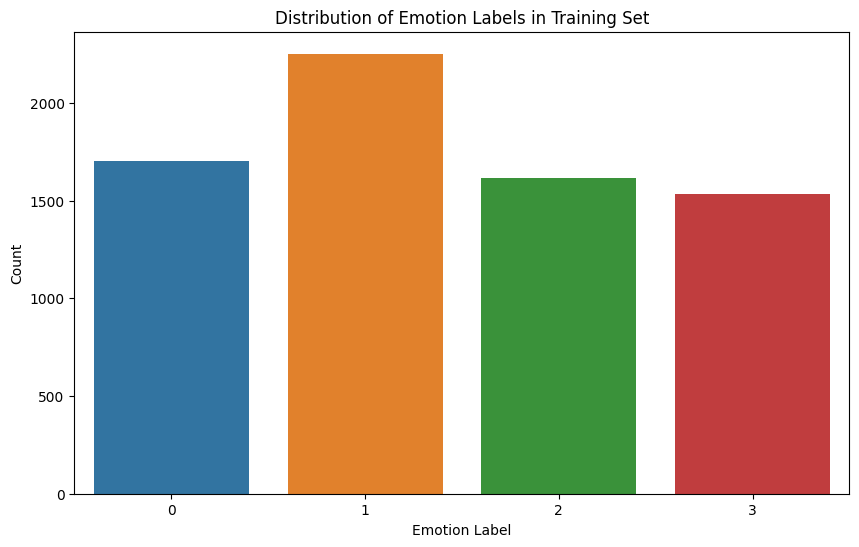

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x=all_labels)
plt.title('Distribution of Emotion Labels in Training Set')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.show()

## 1.5 Preprocessing
Perform the following steps on the tweets in an order of your choosing:
- Tokenize each tweet into words.
- If you think it is useful, use Speller from the autocorrect library to correct spelling mistakes. 
- Create a list of stopwords (using publicly available lists and/or adding your own) and remove these.
- Use PorterStemmer or WordNetLemmatizer from nltk.stem on the text.
- Use regular expressions (the re library) to do any additional cleanup of the text you wish to do.

In [11]:
import re
import nltk
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

try:
    from autocorrect import Speller
    speller = Speller(lang="en")
except Exception:
    speller = None
    print("autocorrect not found; continuing without spelling correction.")

for resource in ["stopwords", "wordnet", "omw-1.4", "averaged_perceptron_tagger"]:
    nltk.download(resource, quiet=True)

tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    "rt", "amp", "im", "ive", "dont", "didnt", "cant", "wont",
    "u", "ur", "via"
}
stop_words = set(stopwords.words("english")).union(custom_stopwords)

def to_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def preprocess_tweet(text, use_speller=False):
    text = str(text).lower()

    # Regex cleanup: URLs, mentions, hashtags, and non-letter characters
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = tokenizer.tokenize(text)

    if use_speller and speller is not None:
        tokens = [speller(t) if t.isalpha() else t for t in tokens]

    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    if tokens:
        tagged = pos_tag(tokens)
        tokens = [lemmatizer.lemmatize(tok, to_wordnet_pos(tag)) for tok, tag in tagged]

    clean_text = " ".join(tokens)
    return tokens, clean_text

def preprocess_dataframe(df, text_col="tweet", use_speller=False):
    processed = df[text_col].apply(lambda x: preprocess_tweet(x, use_speller=use_speller))
    out = df.copy()
    out["tokens"] = processed.apply(lambda x: x[0])
    out["clean_text"] = processed.apply(lambda x: x[1])
    return out

text_col = "tweet" if "tweet" in df_train.columns else "text"
if text_col not in df_train.columns:
    raise KeyError("Expected a text column named 'tweet' or 'text'.")

df_train_pp = preprocess_dataframe(df_train, text_col=text_col, use_speller=False)
df_validation_pp = preprocess_dataframe(df_validation, text_col=text_col, use_speller=False)
df_test_pp = preprocess_dataframe(df_test, text_col=text_col, use_speller=False)

df_train_pp[[text_col, "tokens", "clean_text"]].head()

,text,tokens,clean_text
0,Just got back from seeing @GaryDelaney in Burs...,"[get, back, see, burslem, amaze, face, still, ...",get back see burslem amaze face still hurt lau...
1,Oh dear an evening of absolute hilarity I don'...,"[oh, dear, even, absolute, hilarity, think, la...",oh dear even absolute hilarity think laugh muc...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,"[wait, week, game, cheer, friday]",wait week game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...","[thank, much, gloria, sweet, thoughtful, make,...",thank much gloria sweet thoughtful make day jo...
4,I feel so blessed to work with the family that...,"[feel, bless, work, family, nanny, nothing, lo...",feel bless work family nanny nothing love appr...


## 1.6 Printing Processed Tweets
Print out the words in the first five processed tweets along with their labels. (Viewing this may give you additional ideas for the previous steps.)

In [12]:
for tweet in df_train_pp[['text','clean_text','label']].head(5).iterrows():
    print(f"Tweet: {tweet[1]['text']}")
    print(f"Cleaned Tweet: {tweet[1]['clean_text']}")
    print(f"Label: {tweet[1]['label']}")
    print()

Tweet: Just got back from seeing @GaryDelaney in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious
Cleaned Tweet: get back see burslem amaze face still hurt laugh much hilarious
Label: joy

Tweet: Oh dear an evening of absolute hilarity I don't think I have laughed so much in a long time! 😂
Cleaned Tweet: oh dear even absolute hilarity think laugh much long time
Label: joy

Tweet: Been waiting all week for this game ❤️❤️❤️ #cheer #friday ❤️
Cleaned Tweet: wait week game cheer friday
Label: joy

Tweet: @gardiner_love : Thank you so much, Gloria! You're so sweet, and thoughtful! You just made my day more joyful! I love you too! 😊💕
Cleaned Tweet: thank much gloria sweet thoughtful make day joyful love
Label: joy

Tweet: I feel so blessed to work with the family that I nanny for ❤️ nothing but love &amp; appreciation, makes me smile.
Cleaned Tweet: feel bless work family nanny nothing love appreciation make smile
Label: joy



## 1.7 Histogram Showing the Lengths
Create a histogram showing the lengths of the sequences after preprocessing. Comment on how this helps you to choose the maximum length hyperparameter used when truncating/padding the input sequences.

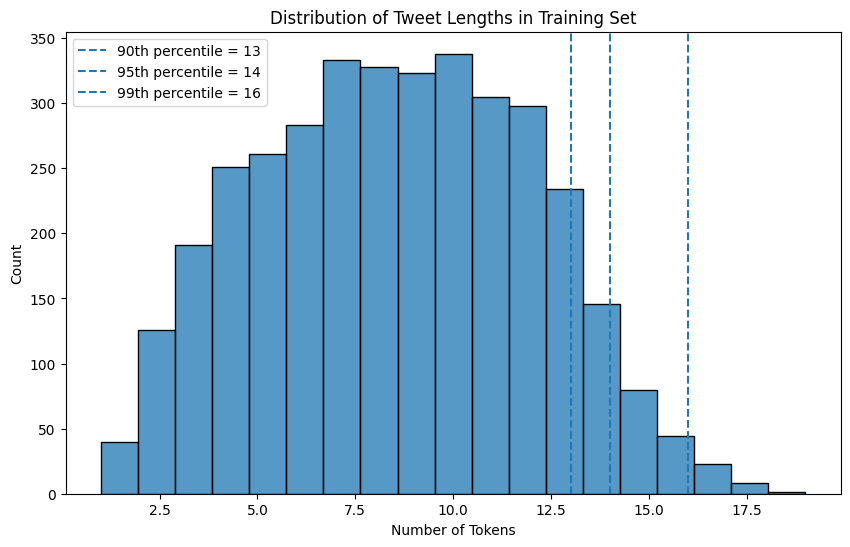

In [13]:
df_train_pp['lenght'] = df_train_pp['tokens'].apply(len)
# Creating a histogram of tweet lengths

p90 = np.percentile(df_train_pp['lenght'], 90)
p95 = np.percentile(df_train_pp['lenght'], 95)
p99 = np.percentile(df_train_pp['lenght'], 99)

plt.figure(figsize=(10, 6))
sns.histplot(df_train_pp['lenght'], bins=19)

plt.axvline(p90, linestyle='--', label=f'90th percentile = {int(p90)}')
plt.axvline(p95, linestyle='--', label=f'95th percentile = {int(p95)}')
plt.axvline(p99, linestyle='--', label=f'99th percentile = {int(p99)}')
 
plt.title('Distribution of Tweet Lengths in Training Set')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.legend()
plt.show()


According to the results we obtained, we decided to pick 16 as our maximun length as it covers 99% of the different lenghts of our tweets tokens, covering most of the length cases.

# 2. Modeling
## 2.1 Tokenizing and Padding preprocessed data
Choose a vocabulary size and fit a tokenizer on the preprocessed data. Use tokenizer.text_to_sequences() to generate a list of index numbers for each tweet. Use padding/truncating to make each sequence the same length, as chosen in step 1.g. above.

### Tokenization Fitting

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 10000
nn_tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
nn_tokenizer.fit_on_texts(df_train_pp["clean_text"])

### Integer Sequences obtention

In [15]:
X_train_seq = nn_tokenizer.texts_to_sequences(df_train_pp["clean_text"])
X_val_seq = nn_tokenizer.texts_to_sequences(df_validation_pp["clean_text"])
X_test_seq = nn_tokenizer.texts_to_sequences(df_test_pp["clean_text"])
X_train_seq[:5]

[[2, 35, 16, 2041, 47, 79, 22, 314, 94, 48, 109],
 [127, 555, 41, 609, 336, 11, 94, 48, 134, 9],
 [80, 69, 121, 114, 610],
 [169, 48, 3590, 368, 2042, 5, 6, 220, 12],
 [17, 399, 37, 369, 3591, 196, 12, 3592, 5, 33]]

In [16]:
maxlen = 16

### Padding

In [21]:
from tensorflow.keras import preprocessing

X_train = preprocessing.sequence.pad_sequences(X_train_seq, maxlen=maxlen)
X_val = preprocessing.sequence.pad_sequences(X_val_seq, maxlen=maxlen)
X_test = preprocessing.sequence.pad_sequences(X_test_seq, maxlen=maxlen)
X_train[:5]

array([[   0,    0,    0,    0,    0,    2,   35,   16, 2041,   47,   79,
          22,  314,   94,   48,  109],
       [   0,    0,    0,    0,    0,    0,  127,  555,   41,  609,  336,
          11,   94,   48,  134,    9],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          80,   69,  121,  114,  610],
       [   0,    0,    0,    0,    0,    0,    0,  169,   48, 3590,  368,
        2042,    5,    6,  220,   12],
       [   0,    0,    0,    0,    0,    0,   17,  399,   37,  369, 3591,
         196,   12, 3592,    5,   33]])

## 2.2 Base Model Creation
Create and compile a model using tf.keras.Sequential to predict the emotion label from the text. Start with an embedding layer and build an architecture from dense, LSTM, GRU, bidirectional LSTM or GRU, and dropout layers. Compile the model using a choice of optimizer, sparse_binary_crossentropy for the loss, and the metric set to accuracy. 

### Model 1 - LSTM

In [18]:
import tensorflow as tf

EMBEDDING_DIM = 64
NUM_CLASSES = len(le.classes_)

tf.random.set_seed(42)

model1 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size,
                              output_dim=EMBEDDING_DIM,
                              input_length=maxlen),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
], name='Model_1_LSTM')

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

Model: "Model_1_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 16, 64)            640000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 4)                 132       
                                                                 
Total params: 675,236
Trainable params: 675,236
Non-trainable params: 0
_________________________________________________________________


## 2.3 Training the Base Model
Train the model on the training data without using a validation split. Calculate and record the training accuracy.


In [19]:
history1 = model1.fit(
    X_train, df_train_labels,
    epochs=10,
    batch_size=64,
    verbose=1
)

train_acc_m1 = history1.history['accuracy'][-1]
print(f"\nModel 1 – Final Training Accuracy: {train_acc_m1:.4f}")

Epoch 1/10
57/57 [==============================] - 2s 14ms/step - loss: 1.3640 - accuracy: 0.3352
Epoch 2/10
57/57 [==============================] - 1s 14ms/step - loss: 0.9014 - accuracy: 0.6457
Epoch 3/10
57/57 [==============================] - 1s 15ms/step - loss: 0.3087 - accuracy: 0.9023
Epoch 4/10
57/57 [==============================] - 1s 15ms/step - loss: 0.1532 - accuracy: 0.9577
Epoch 5/10
57/57 [==============================] - 1s 14ms/step - loss: 0.1002 - accuracy: 0.9740
Epoch 6/10
57/57 [==============================] - 1s 15ms/step - loss: 0.0878 - accuracy: 0.9726
Epoch 7/10
57/57 [==============================] - 1s 14ms/step - loss: 0.0710 - accuracy: 0.9779
Epoch 8/10
57/57 [==============================] - 1s 14ms/step - loss: 0.0651 - accuracy: 0.9779
Epoch 9/10
57/57 [==============================] - 1s 15ms/step - loss: 0.0538 - accuracy: 0.9817
Epoch 10/10
57/57 [==============================] - 1s 15ms/step - loss: 0.0480 - accuracy: 0.9828

Model 1 

## 2.4 Running the model on Validation Dataset
Use the model to make predictions on the validation data. Calculate and record the validation accuracy. Display the confusion matrix for the validation data. Use markdown to make comments.
### Helper Function
We are using a function that creates a confusion Matrix of the performance on validation and also shows the accuracy of the model.

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

CLASS_NAMES = list(le.classes_) 

def evaluate_model(model, X, y_true, split_name="Validation"):
    """Return accuracy and display a labelled confusion matrix."""
    y_prob = model.predict(X, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)
    print(f"{split_name} accuracy: {acc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{split_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return acc, y_pred

results = {} 

### Testing the model on Validation Dataset

Model 1 Validation accuracy: 0.7579


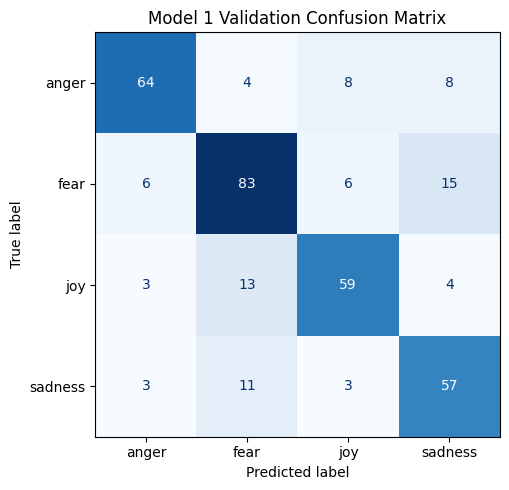

In [22]:
val_acc_m1, _ = evaluate_model(model1, X_val, df_validation_labels, split_name="Model 1 Validation")
results['Model 1 – LSTM'] = {'Training Acc': round(train_acc_m1, 4),
                              'Validation Acc': round(val_acc_m1, 4)}

## 2.5 Creating More Models Using different architectures
Revisit the previous steps to make at least three models in total by changing architecture and hyperparameters.


### 2.5.1 Comparison Setup
The three models below are designed to reduce overfitting compared to Model 1. They all use early stopping and learning-rate reduction on plateau.

In [23]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Dense, Dropout, LSTM, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

if "results" not in globals():
    results = {}

VOCAB_SIZE_USED = min(vocab_size, len(nn_tokenizer.word_index) + 1)

def get_callbacks():
    return [
        EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
    ]

def train_and_validate(model, model_name, epochs=15, batch_size=64):
    history = model.fit(
        X_train, df_train_labels,
        validation_data=(X_val, df_validation_labels),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_callbacks(),
        verbose=1
    )
    train_acc = history.history["accuracy"][-1]
    val_acc, _ = evaluate_model(
        model, X_val, df_validation_labels, split_name=f"{model_name} Validation"
    )
    results[model_name] = {
        "Training Acc": round(float(train_acc), 4),
        "Validation Acc": round(float(val_acc), 4)
    }
    return history, train_acc, val_acc

### 2.5.2 Model 2 - Bidirectional GRU
A bidirectional GRU often captures sequence context better while staying lighter than stacked LSTMs.

Model: "Model_2_BiGRU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 16, 128)           903040    
                                                                 
 bidirectional (Bidirectiona  (None, 128)              74496     
 l)                                                              
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 4)                 260       
                                                                 
Total params: 986,052
Trainable params: 986,052
Non-trainable params: 0
_______________________________________________

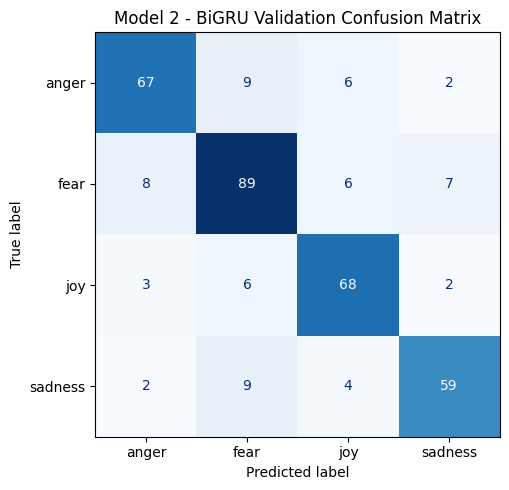

In [24]:
tf.random.set_seed(42)

model2 = tf.keras.Sequential([
    Embedding(input_dim=VOCAB_SIZE_USED, output_dim=128, input_length=maxlen),
    Bidirectional(GRU(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="softmax")
], name="Model_2_BiGRU")

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

history2, train_acc_m2, val_acc_m2 = train_and_validate(
    model2, model_name="Model 2 - BiGRU", epochs=15, batch_size=64
)

### 2.5.3 Model 3 - Stacked Bidirectional LSTM
This model is deeper and can capture more complex temporal patterns, with dropout to control overfitting.

Model: "Model_3_Stacked_BiLSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 16, 128)           903040    
                                                                 
 bidirectional_1 (Bidirectio  (None, 16, 128)          98816     
 nal)                                                            
                                                                 
 bidirectional_2 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 4)      

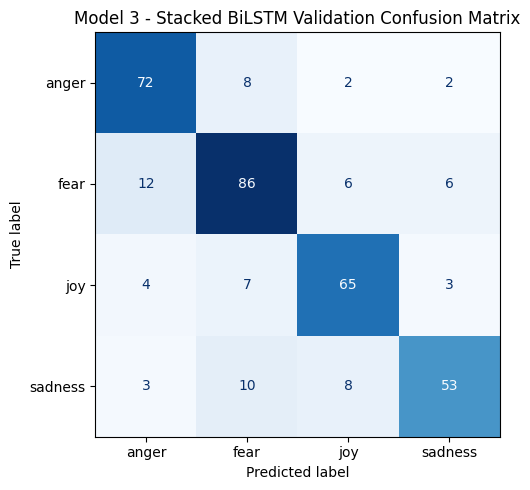

In [25]:
tf.random.set_seed(42)

model3 = tf.keras.Sequential([
    Embedding(input_dim=VOCAB_SIZE_USED, output_dim=128, input_length=maxlen),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="softmax")
], name="Model_3_Stacked_BiLSTM")

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model3.summary()

history3, train_acc_m3, val_acc_m3 = train_and_validate(
    model3, model_name="Model 3 - Stacked BiLSTM", epochs=15, batch_size=64
)

### 2.5.4 Model 4 - Stacked GRU with L2 Regularization
This model uses two GRU layers and L2 regularization on the dense layer to further reduce overfitting.

Model: "Model_4_Stacked_GRU_L2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 16, 100)           705500    
                                                                 
 gru_1 (GRU)                 (None, 16, 64)            31872     
                                                                 
 gru_2 (GRU)                 (None, 32)                9408      
                                                                 
 dense_6 (Dense)             (None, 64)                2112      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 4)                 260       
                                                                 
Total params: 749,152
Trainable params: 749,

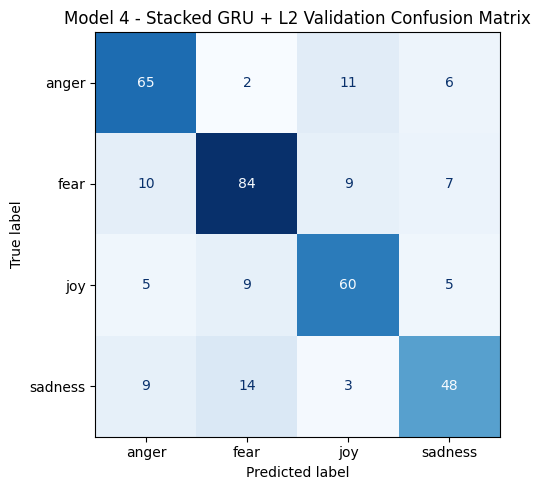

In [26]:
tf.random.set_seed(42)

model4 = tf.keras.Sequential([
    Embedding(input_dim=VOCAB_SIZE_USED, output_dim=100, input_length=maxlen),
    GRU(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    GRU(32, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation="softmax")
], name="Model_4_Stacked_GRU_L2")

model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model4.summary()

history4, train_acc_m4, val_acc_m4 = train_and_validate(
    model4, model_name="Model 4 - Stacked GRU + L2", epochs=15, batch_size=64
)

### 2.5.5 Model Comparison
Sort by validation accuracy to select the best model for the next steps.

In [27]:
results_df = pd.DataFrame(results).T.sort_values("Validation Acc", ascending=False)
results_df

,Training Acc,Validation Acc
Model 2 - BiGRU,0.9831,0.8156
Model 3 - Stacked BiLSTM,0.9828,0.7954
Model 1 – LSTM,0.9828,0.7579
Model 4 - Stacked GRU + L2,0.9806,0.7406
